# EDA sur le dataset de séries et films (omdb) pour les années 2016-2026

## Import & Configuration

In [5]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Configuration esthétique pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14

In [8]:
# 1. Définition du chemin relatif depuis le dossier notebooks/
# Remplace les '...' par la fin exacte du nom de ton fichier si besoin
file_name = "omdb_raw.json" 
raw_data_path = os.path.join("..", "data", "raw", file_name)

# 2. Chargement du dataset
try:
    df_omdb = pd.read_json(raw_data_path)
    print("✅ Dataset chargé avec succès !")
    print(f"Dimensions du dataset : {df_omdb.shape[0]} lignes et {df_omdb.shape[1]} colonnes.\n")
except FileNotFoundError:
    print(f"❌ Erreur : Le fichier n'a pas été trouvé au chemin : {raw_data_path}")
    print("Vérifie bien l'extension et l'orthographe exacte du nom du fichier.")

# 3. Premier aperçu des données
df_omdb.info()

✅ Dataset chargé avec succès !
Dimensions du dataset : 199 lignes et 27 colonnes.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         199 non-null    object 
 1   Year          199 non-null    object 
 2   Rated         199 non-null    object 
 3   Released      199 non-null    object 
 4   Runtime       199 non-null    object 
 5   Genre         199 non-null    object 
 6   Director      199 non-null    object 
 7   Writer        199 non-null    object 
 8   Actors        199 non-null    object 
 9   Plot          199 non-null    object 
 10  Language      199 non-null    object 
 11  Country       199 non-null    object 
 12  Awards        199 non-null    object 
 13  Poster        199 non-null    object 
 14  Ratings       199 non-null    object 
 15  Metascore     199 non-null    object 
 16  imdbRating    199 non-null    flo

In [13]:
df_omdb.head().T

,0,1,2,3,4
Title,Stranger Things,Joker,Avengers: Endgame,Avengers: Infinity War,Deadpool
Year,2016–2025,2019,2019,2018,2016
Rated,TV-MA,R,PG-13,PG-13,R
Released,15 Jul 2016,04 Oct 2019,26 Apr 2019,27 Apr 2018,12 Feb 2016
Runtime,51 min,122 min,181 min,149 min,108 min
Genre,"Drama, Fantasy, Horror","Crime, Drama, Thriller","Action, Adventure, Sci-Fi","Action, Adventure, Sci-Fi","Action, Comedy, Sci-Fi"
Director,N/A,Todd Phillips,"Anthony Russo, Joe Russo","Anthony Russo, Joe Russo",Tim Miller
Writer,"Matt Duffer, Ross Duffer","Todd Phillips, Scott Silver, Bob Kane","Christopher Markus, Stephen McFeely, Stan Lee","Christopher Markus, Stephen McFeely, Stan Lee","Rhett Reese, Paul Wernick"
Actors,"Millie Bobby Brown, Finn Wolfhard, Winona Ryder","Joaquin Phoenix, Robert De Niro, Zazie Beetz","Robert Downey Jr., Chris Evans, Mark Ruffalo","Robert Downey Jr., Chris Hemsworth, Mark Ruffalo","Ryan Reynolds, Morena Baccarin, T.J. Miller"
Plot,"In 1980s Indiana, a group of young friends wit...","Arthur Fleck, a party clown and a failed stand...",After the devastating events of Avengers: Infi...,The Avengers and their allies must be willing ...,A wisecracking mercenary gets experimented on ...


## Analyse des valeurs manquantes

In [9]:
print("Analyse de la propreté des colonnes (Détection des faux 'N/A') :\n")

metrics = []
for col in df_omdb.columns:
    # Compte le nombre de chaînes 'N/A' (insensible à la casse)
    na_text_count = df_omdb[col].astype(str).str.strip().str.upper().isin(['N/A', 'NAN', '', 'NONE']).sum()
    na_percent = (na_text_count / len(df_omdb)) * 100
    
    metrics.append({
        "Colonne": col,
        "Nombre_NA_Textuels": na_text_count,
        "Pourcentage_NA": round(na_percent, 2),
        "Type_Actuel": str(df_omdb[col].dtypes)
    })

df_audit_na = pd.DataFrame(metrics).sort_values(by="Pourcentage_NA", ascending=False)
print(df_audit_na.to_string(index=False))

Analyse de la propreté des colonnes (Détection des faux 'N/A') :

     Colonne  Nombre_NA_Textuels  Pourcentage_NA Type_Actuel
     Website                 199          100.00      object
         DVD                 198           99.50      object
  Production                 196           98.49      object
totalSeasons                 166           83.42     float64
   BoxOffice                  43           21.61      object
   Metascore                  34           17.09      object
    Director                  32           16.08      object
     Runtime                  10            5.03      object
       Rated                   1            0.50      object
      Writer                   1            0.50      object
  imdbRating                   0            0.00     float64
    numVotes                   0            0.00       int64
    Response                   0            0.00      object
        Type                   0            0.00      object
      imdbID       

In [15]:
# 1. Création d'un dataset temporaire où les 'N/A' deviennent des vrais NaN
df_missing_audit = df_omdb[['Type', 'Metascore', 'BoxOffice']].copy()
df_missing_audit = df_missing_audit.replace(['N/A', 'N/A ', ' n/a'], np.nan)

# 2. Calcul du taux de données manquantes (en %) par Type de production
# Remplacement de apply() par un calcul direct sur les colonnes numériques pour éviter le conflit Pylance
missing_rates = df_missing_audit.groupby('Type')[['Metascore', 'BoxOffice']].agg(
    lambda col: col.isna().mean() * 100
)

# Réorganisation des données pour le plot (Format Long/Melt)
missing_rates_melted = missing_rates.reset_index().melt(
    id_vars='Type', 
    value_vars=['Metascore', 'BoxOffice'], 
    var_name='Variable', 
    value_name='Pourcentage_Manquants'
)

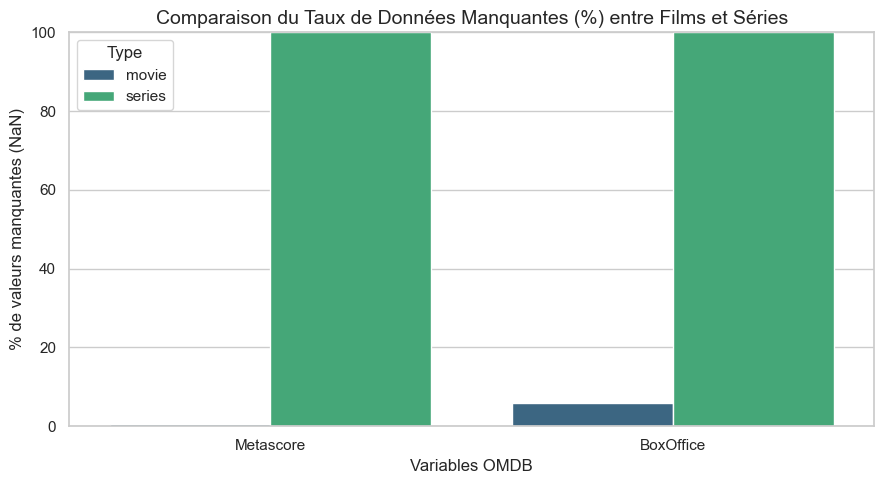

In [16]:
# 3. Génération du graphique
plt.figure(figsize=(9, 5))
sns.barplot(data=missing_rates_melted, x='Variable', y='Pourcentage_Manquants', hue='Type', palette='viridis')
plt.title("Comparaison du Taux de Données Manquantes (%) entre Films et Séries")
plt.xlabel("Variables OMDB")
plt.ylabel("% de valeurs manquantes (NaN)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Distribution du type de distribution

📋 Répartition brute des types de productions dans le fichier JSON :
Type
movie     166
series     33
Name: count, dtype: int64


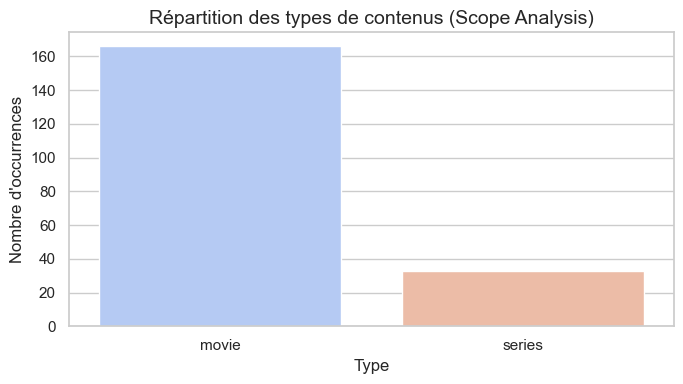

In [10]:
print("📋 Répartition brute des types de productions dans le fichier JSON :")
type_counts = df_omdb['Type'].value_counts(dropna=False)
print(type_counts)

# Visualisation rapide
plt.figure(figsize=(7, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette='coolwarm', legend=False)
plt.title("Répartition des types de contenus (Scope Analysis)")
plt.xlabel("Type")
plt.ylabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()

## Audit des variables

In [11]:
print("Échantillon des formats de chaînes qui bloquent les calculs :\n")

cols_to_audit = ['BoxOffice', 'imdbVotes', 'Runtime', 'Year']

for col in cols_to_audit:
    if col in df_omdb.columns:
        print(f"🔹 Exemples pour la colonne '{col}' :")
        # On prend un échantillon de valeurs uniques qui ne sont pas nulles ni égales à 'N/A'
        valid_samples = df_omdb[~df_omdb[col].astype(str).str.upper().isin(['N/A', 'NAN'])][col].unique()[:5]
        print(f"   Values: {valid_samples}\n")

Échantillon des formats de chaînes qui bloquent les calculs :

🔹 Exemples pour la colonne 'BoxOffice' :
   Values: ['$335,477,657' '$858,373,000' '$678,815,482' '$363,070,709' '$53,847,897']

🔹 Exemples pour la colonne 'imdbVotes' :
   Values: ['1,691,532' '1,690,149' '1,442,446' '1,368,739' '1,250,978']

🔹 Exemples pour la colonne 'Runtime' :
   Values: ['51 min' '122 min' '181 min' '149 min' '108 min']

🔹 Exemples pour la colonne 'Year' :
   Values: ['2016–2025' '2019' '2018' '2016' '2021']

